In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import Dataset
import pandas as pd
import numpy as np
import torchvision.transforms as transforms
import os
from PIL import Image
from easydict import EasyDict as edict



In [2]:
class CelebADataset(Dataset):
    def __init__(self, root_dir, transform=None):
        
        self.root_dir = root_dir
        self.image_files = sorted([
            f for f in os.listdir(root_dir) if f.endswith('.jpg')
        ])
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img

class FashionMNISTDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform or transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((32, 32)),  
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx].values
        label = int(row[0])
        image = row[1:].astype(np.uint8).reshape(28, 28) 
        image = np.expand_dims(image, axis=2)  
        image = self.transform(image)

        return image, image, label 


# Model AE

In [3]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 8x8
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),# 4x4
            nn.ReLU(),
            nn.Flatten(),                                          # 2048
            nn.Linear(2048, 2)                                     # bottleneck
        )

    def forward(self, x):
        return self.encoder(x)

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.Linear(2, 2048),
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(x)

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

# Model VAE

In [4]:
class EncoderVAE(nn.Module):
    def __init__(self):
        super(EncoderVAE, self).__init__()

        # inputan 1 x 32 x 32 > 32 x 16 x 16
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1) 
        
        # inputan 32 x 16 x 16 > 64 x 8 x 8
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)

        # inputan 64 x 8 x 8 > 128 x 4 x 4
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)

        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()

        self.fc_mu = nn.Linear(128 * 4 * 4, 2)
        self.fc_logvar = nn.Linear(128 * 4 * 4, 2)

    def _reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))

        x = self.flatten(x)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self._reparameterize(mu, logvar)

        return z, mu, logvar

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = EncoderVAE()
        self.decoder = Decoder()

    def forward(self, x):
        z, mu, logvar = self.encoder(x)
        out = self.decoder(z)
        return out, mu, logvar

# Train

In [5]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss  + beta * kl_loss, recon_loss, kl_loss
    
def main(args):
    train_dataset = FashionMNISTDataset('/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv')
    
    train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    if args.model_name == 'AE':
        model = Autoencoder().to(device)
    elif args.model_name == 'VAE':
        model = VAE().to(device)
       
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=args.lr)
    
    epochs = args.epochs
    
    train_loss, recon_losses, kl_losses = [], [], []

    for epoch in range(epochs):
        total_loss = 0
        total_recon = 0
        total_kl = 0
        for imgs, _, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            imgs = imgs.to(device)
            
            if args.model_name == 'AE':
                outputs = model(imgs)
                loss = criterion(outputs, imgs)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
    
                total_loss += loss.item()
            elif args.model_name == 'VAE':
                recon, mu, logvar = model(imgs)
                loss, recon_loss, kl_loss = vae_loss(recon, imgs, mu, logvar)
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
    
                total_loss += loss.item()
                total_recon += recon_loss.item()
                total_kl += kl_loss.item()
    
        train_loss.append(total_loss / len(train_loader))
        
        recon_losses.append(total_recon / len(train_loader))
        kl_losses.append(total_kl / len(train_loader))
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")
    
    torch.save(model.state_dict(), 'model_'+args.model_name+'.pth')

In [6]:
def show_reconstruction(args):
    test_dataset = FashionMNISTDataset('/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv')
    
    test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    if args.model_name == 'AE':
        model = Autoencoder().to(device)
    elif args.model_name == 'VAE':    
        model = VAE().to(device)
    
    model.load_state_dict(torch.load("model_"+args.model_name+".pth", map_location=device, weights_only=True))
    model.eval()
    with torch.no_grad():
        test_imgs, _,_ = next(iter(test_loader))
        test_imgs = test_imgs.to(device)

        if args.model_name == 'AE':
            outputs = model(test_imgs)
        elif args.model_name == 'VAE':
            outputs, _, _ = model(test_imgs)

        n = 10
        plt.figure(figsize=(20, 4))
        for i in tqdm(range(n),desc="showing reconstruction"):
            
            ax = plt.subplot(2, n, i + 1)
            plt.imshow(test_imgs[i].cpu().squeeze(), cmap='gray')
            ax.axis("off")
            
            ax = plt.subplot(2, n, i + 1 + n)
            plt.imshow(outputs[i].cpu().squeeze(), cmap='gray')
            ax.axis("off")
        plt.show()


In [7]:
from easydict import EasyDict as edict

args = edict(
    {
        "lr": 1e-3,
        "batch_size": 128,
        "epochs": 10,
        "model_name": "VAE",
    }
)

main(args)


Epoch 1: 100%|██████████| 469/469 [00:25<00:00, 18.66it/s]


Epoch [1/10], Loss: 50521.4934


Epoch 2: 100%|██████████| 469/469 [00:23<00:00, 20.27it/s]


Epoch [2/10], Loss: 45641.5601


Epoch 3: 100%|██████████| 469/469 [00:23<00:00, 20.22it/s]


...

Epoch [8/10], Loss: 44493.1284


Epoch 9: 100%|██████████| 469/469 [00:23<00:00, 20.22it/s]


Epoch [9/10], Loss: 44404.6461


Epoch 10: 100%|██████████| 469/469 [00:23<00:00, 20.03it/s]

Epoch [10/10], Loss: 44343.2915


showing reconstruction: 100%|██████████| 10/10 [00:00<00:00, 59.95it/s]


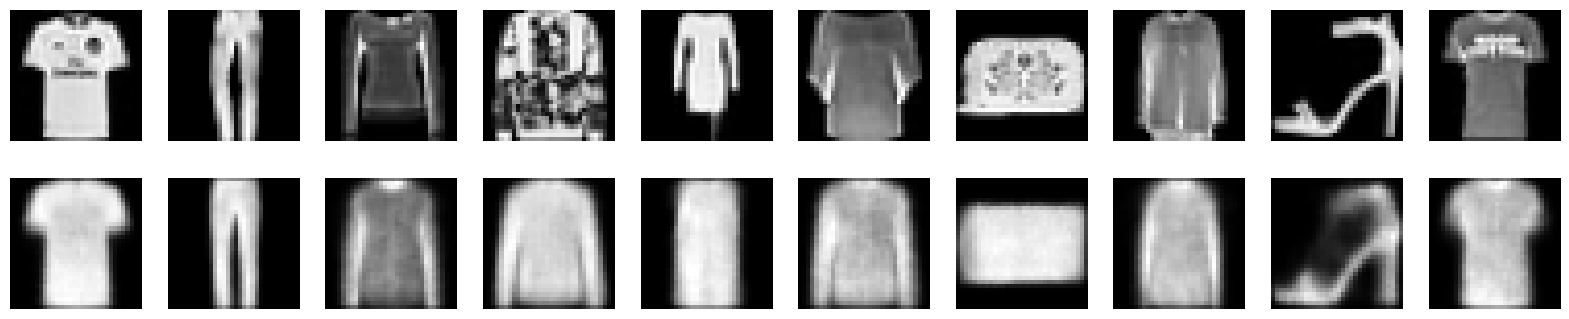

In [8]:
show_reconstruction(args)

In [9]:
def generate_from_random_z(model, device, n=8, z_dim=2):
    model.eval()

    z = torch.randn(n, z_dim).to(device)

    print("Representasi Laten",z)

    with torch.no_grad():
        generated = model.decoder(z)

    generated = generated.cpu()

    plt.figure(figsize=(12, 3))

    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(generated[i].squeeze(), cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Representasi Laten tensor([[ 1.4834e+00,  1.4429e+00],
        [ 2.2372e+00, -4.6982e-01],
        [ 7.6746e-01, -3.0230e-01],
        [ 2.7212e-01, -9.9870e-04],
        [-9.2646e-01,  1.6693e+00],
        [ 3.5695e-01, -1.1636e+00],
        [ 4.4233e-01, -3.1892e-01],
        [ 8.3266e-02,  7.2089e-01]], device='cuda:0')


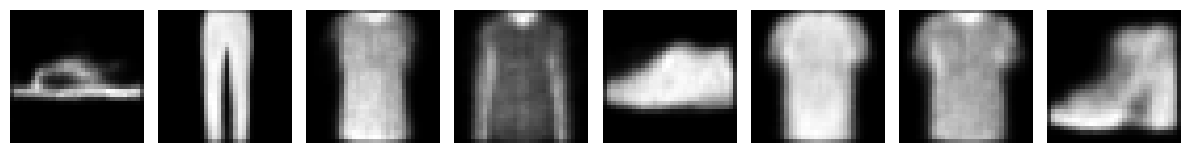

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if args.model_name == 'AE':
    model = Autoencoder().to(device)
elif args.model_name == 'VAE':    
    model = VAE().to(device)

model.load_state_dict(torch.load("model_"+args.model_name+".pth", map_location=device, weights_only=True))

generate_from_random_z(model, device, n=8, z_dim=2)

In [11]:
def collect_latent_by_label(model, dataloader, device, target_label=0, max_samples=500):
    model.eval()

    latents = []

    with torch.no_grad():
        for imgs, _, labels in dataloader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            mask = labels == target_label

            if mask.sum() == 0:
                continue

            selected_imgs = imgs[mask]

            z, mu, logvar = model.encoder(selected_imgs)

            latents.append(mu.cpu())

            total = sum(x.shape[0] for x in latents)
            if total >= max_samples:
                break

    if len(latents) == 0:
        raise ValueError(f"Tidak ada data dengan label {target_label}")

    latents = torch.cat(latents, dim=0)
    latents = latents[:max_samples]

    return latents

In [12]:
def generate_clothes_from_label_area(model, dataloader, device, target_label=0, n=16, noise_scale=0.5):
    model.eval()

    latents = collect_latent_by_label(
        model=model,
        dataloader=dataloader,
        device=device,
        target_label=target_label,
        max_samples=500
    )

    center = latents.mean(dim=0)
    std = latents.std(dim=0)

    z = center + noise_scale * std * torch.randn(n, center.shape[0])
    z = z.to(device)

    with torch.no_grad():
        generated = model.decoder(z)

    generated = generated.cpu()

    plt.figure(figsize=(10, 4))

    for i in range(n):
        plt.subplot(2, n // 2, i + 1)
        plt.imshow(generated[i].squeeze(), cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

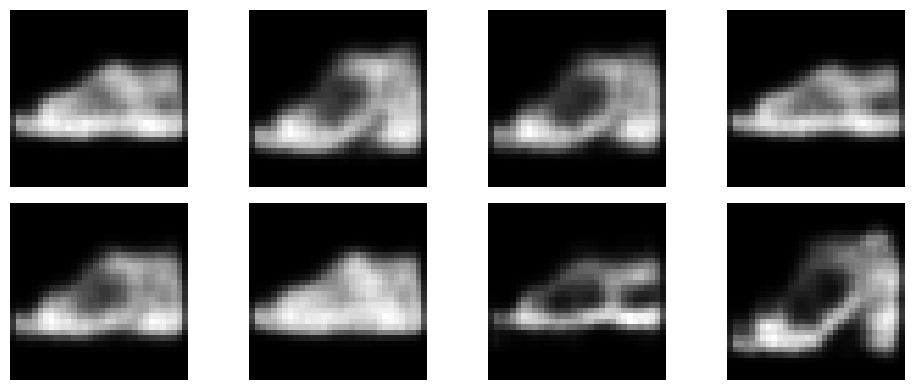

In [16]:
label_names = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}


test_dataset = FashionMNISTDataset('/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv')
    
test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False)
generate_clothes_from_label_area(
    model,
    test_loader,
    device,
    target_label=5,
    n=8,
    noise_scale=0.5
)